# 1. Pie charts

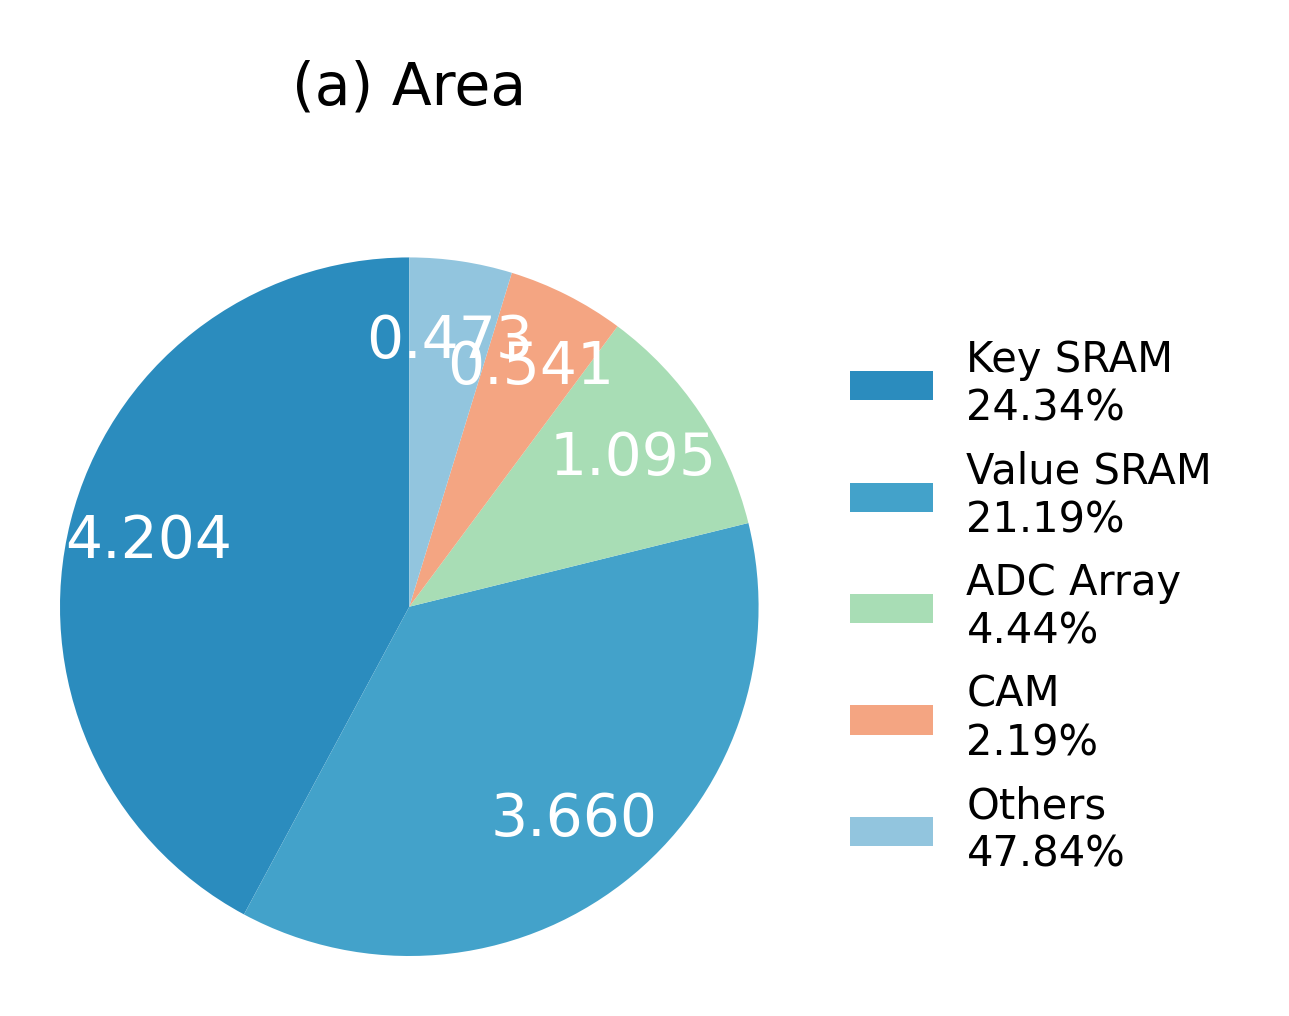

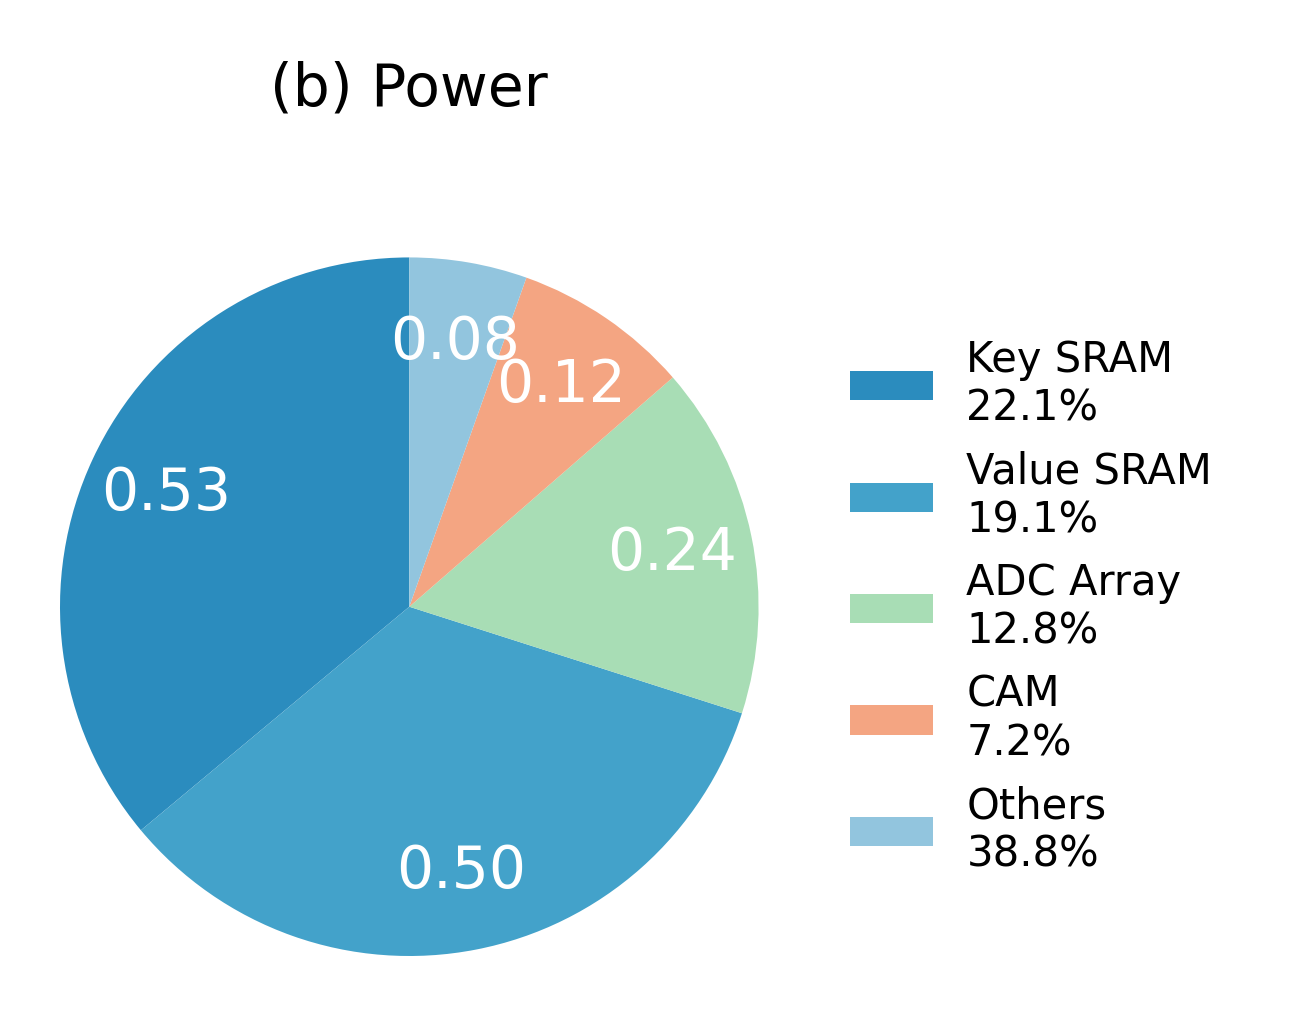

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data for 128x128 configuration
area_values = [4.204, 3.660, 1.095, 0.541, 0.473]  # in mm2
power_values = [0.53, 0.50, 0.24, 0.12, 0.08]  # in W
labels = ['Key SRAM', 'Value SRAM', 'ADC Array', 'CAM', 'Others']
area_percentages = [24.34, 21.19, 4.44, 2.19, 47.84]
power_percentages = [22.1, 19.1, 12.8, 7.2, 38.8]

# Area Plot
fig1, ax1 = plt.subplots(figsize=(3*0.9, 2*0.9), dpi=600)
wedges1, texts1, autotexts1 = ax1.pie(area_values,
                                     colors=['#2b8cbe', '#43a2ca', '#a8ddb5', '#f4a582', '#92c5de'],
                                     autopct='',
                                     startangle=90,
                                     radius=1.3)

# Add title
ax1.set_title('(a) Area', pad=20, fontsize=7)

# Add value labels inside the pie slices
for i, wedge in enumerate(wedges1):
    x, y = wedge.center
    angle = np.pi/180 * (wedge.theta1 + wedge.theta2) / 2
    x = x + 1 * np.cos(angle)
    y = y + 1 * np.sin(angle)
    ax1.text(x, y, f'{area_values[i]:.3f}', ha='center', va='center', color='white', fontsize=7)

# Create legend with vertical stacking
legend_labels = [f'{labels[i]}\n{area_percentages[i]}%' for i in range(len(labels))]
ax1.legend(wedges1, legend_labels,
          loc='center left',
          bbox_to_anchor=(1.1, 0.5),
          frameon=False,
          fontsize=5,
          ncol=1)  # This ensures vertical stacking

plt.tight_layout()
plt.show()

# Power Plot
fig2, ax2 = plt.subplots(figsize=(3*0.9, 2*0.9), dpi=600)
wedges2, texts2, autotexts2 = ax2.pie(power_values,
                                     colors=['#2b8cbe', '#43a2ca', '#a8ddb5', '#f4a582', '#92c5de'],
                                     autopct='',
                                     startangle=90,
                                     radius=1.3)

# Add title
ax2.set_title('(b) Power', pad=20, fontsize=7)

# Add value labels inside the pie slices
for i, wedge in enumerate(wedges2):
    x, y = wedge.center
    angle = np.pi/180 * (wedge.theta1 + wedge.theta2) / 2
    x = x + 1 * np.cos(angle)
    y = y + 1 * np.sin(angle)
    ax2.text(x, y, f'{power_values[i]:.2f}', ha='center', va='center', color='white', fontsize=7)

# Create legend with vertical stacking
legend_labels = [f'{labels[i]}\n{power_percentages[i]}%' for i in range(len(labels))]
ax2.legend(wedges2, legend_labels,
          loc='center left',
          bbox_to_anchor=(1.1, 0.5),
          frameon=False,
          fontsize=5,
          ncol=1)  # This ensures vertical stacking

plt.tight_layout()
plt.show()

# 2.Speed up bars

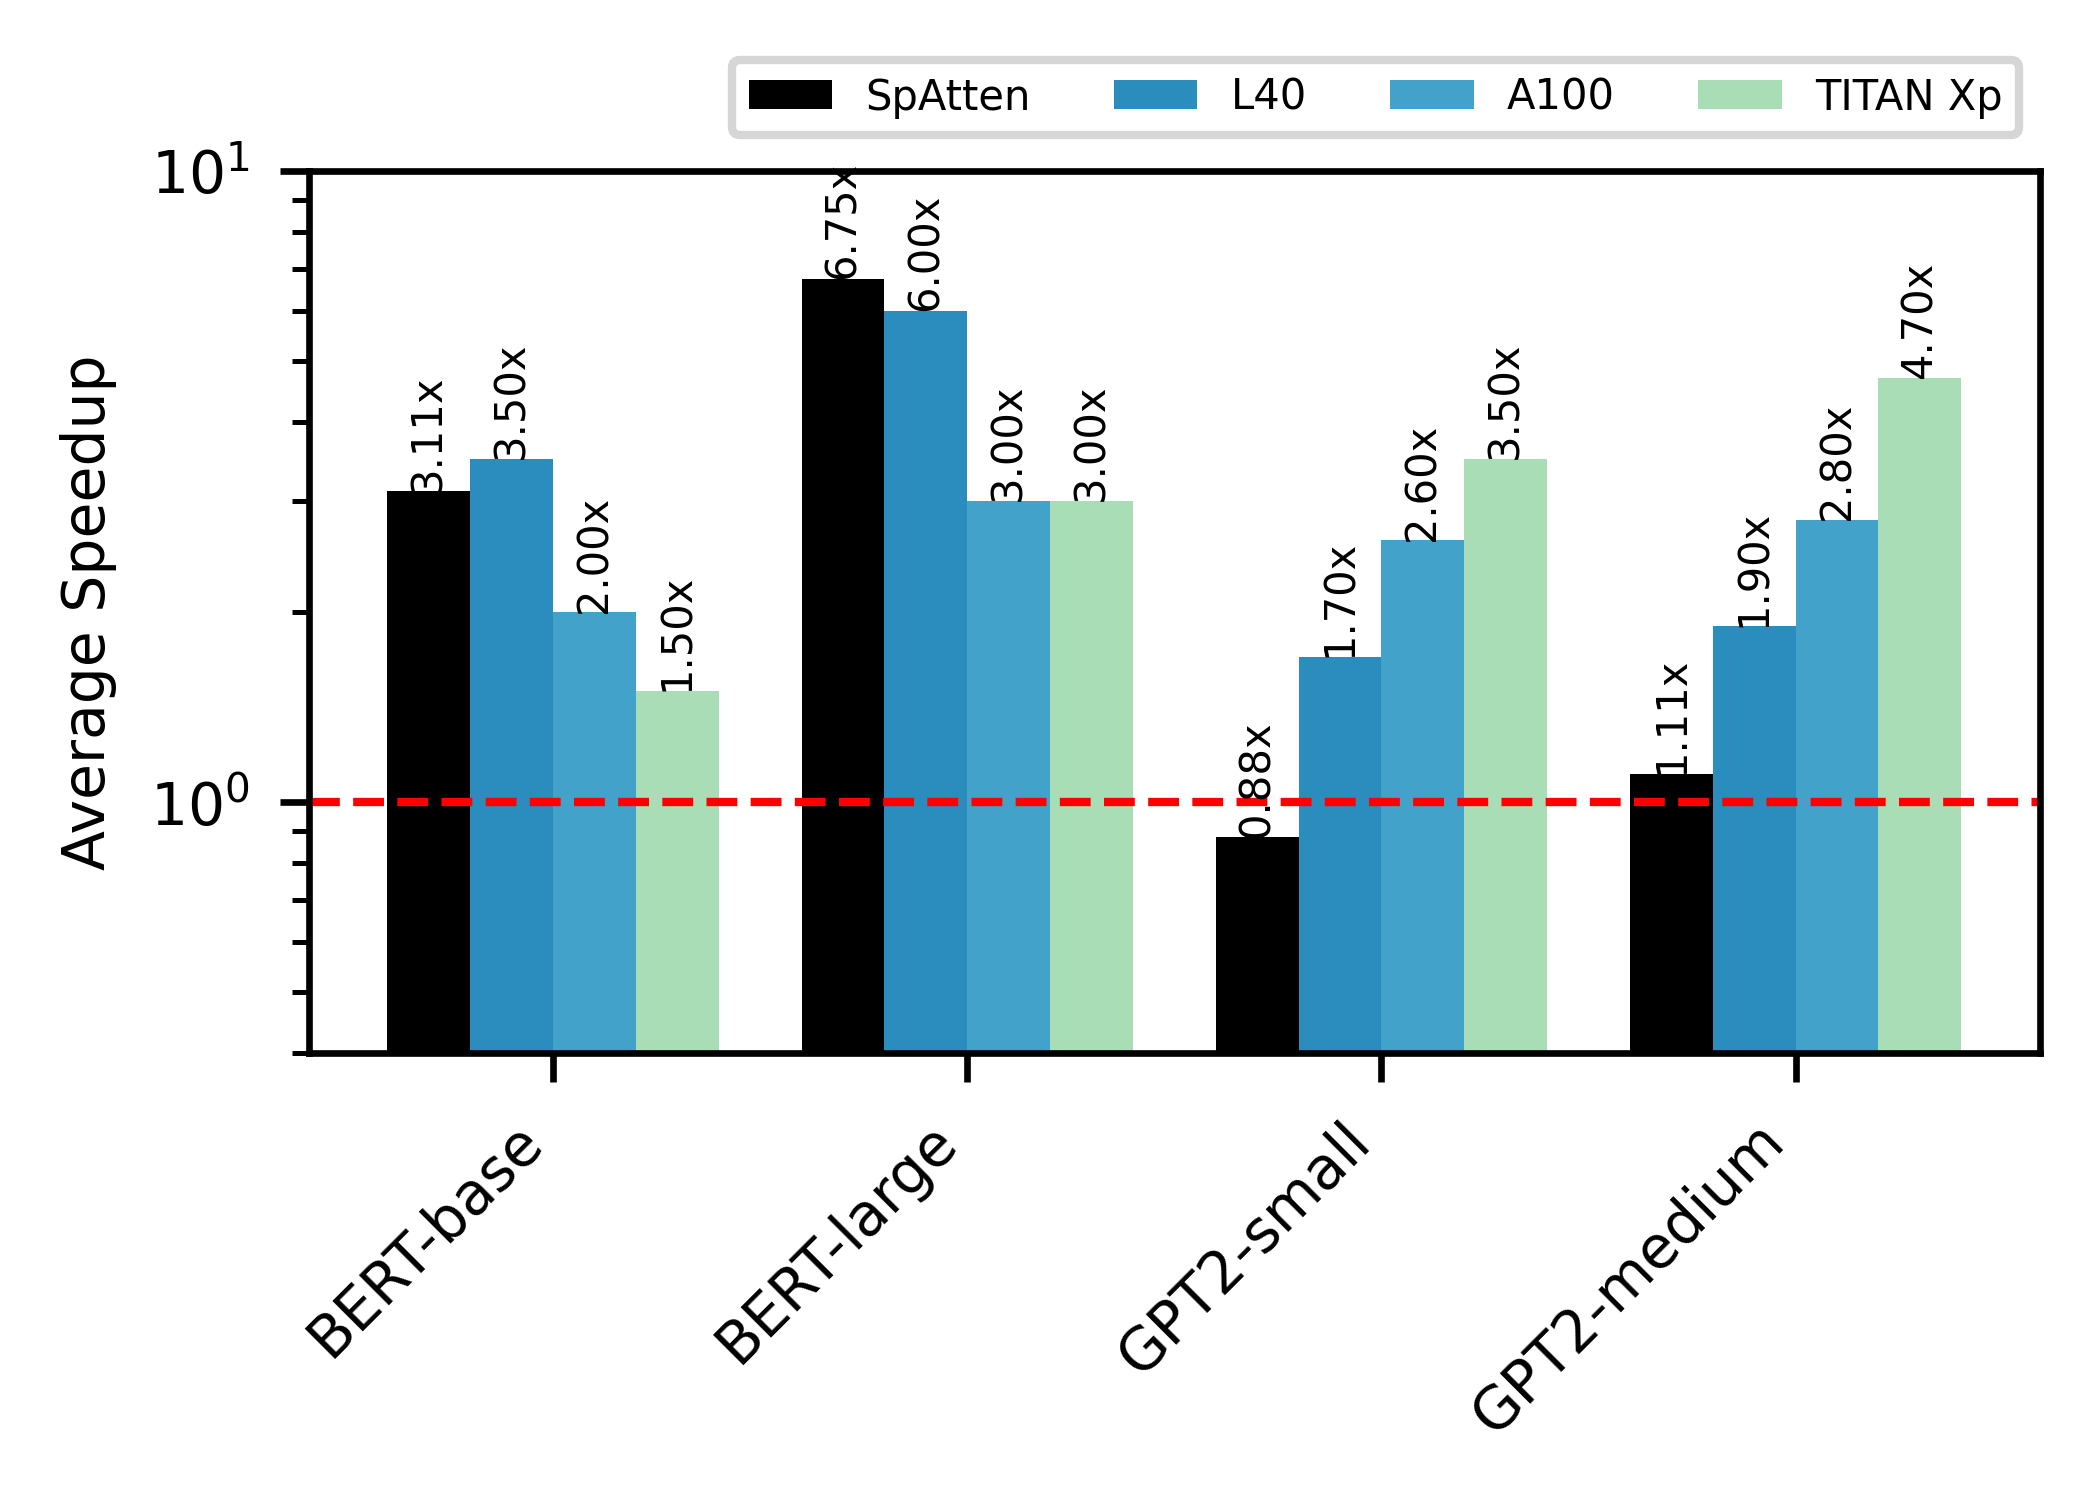

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data
model_types = ['BERT-base', 'BERT-large', 'GPT2-small', 'GPT2-medium']
devices = ['SpAtten', 'L40', 'A100', 'TITAN Xp']
colors = ['black', '#2b8cbe', '#43a2ca', '#a8ddb5']  # Different color for each device

# Example speedups for each device (replace with actual data)
speedups = {
    'SpAtten': [3.11, 6.75, 0.88, 1.11],  # Your actual data
    'L40': [3.5, 6.0, 1.7, 1.9],          # Replace with actual data
    'A100': [2.0, 3.0, 2.6, 2.8],         # Replace with actual data
    'TITAN Xp': [1.5, 3.0, 3.5, 4.7]      # Replace with actual data
}

# Set up the plot
fig, ax = plt.subplots(figsize=(4*0.9, 3*0.9), dpi=600)

# Set the width of each bar and positions of the bars
width = 0.2
x = np.arange(len(model_types))

# Create bars for each device
for i, device in enumerate(devices):
    offset = width * (i - len(devices)/2 + 0.5)
    bars = ax.bar(x + offset, speedups[device], width, label=device, color=colors[i])

    # Add value labels on top of bars
    for j, bar in enumerate(bars):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{speedups[device][j]:.2f}x',
                ha='center', va='bottom', fontsize=5, rotation=90)

# Customize the plot
ax.set_ylabel('Average Speedup', fontsize=7)
ax.set_xticks(x)
ax.set_xticklabels(model_types, rotation=45, ha='right', fontsize=7)
ax.tick_params(axis='y', labelsize=7)

# Add horizontal line at y=1
ax.axhline(y=1, color='red', linestyle='--', linewidth=1)

# Set y-axis to log scale
ax.set_yscale('log')
ax.set_ylim(0.4, 10)

# Add legend
ax.legend(fontsize=5, ncol=4, bbox_to_anchor=(1.0, 1.15))

# Adjust layout
plt.tight_layout()

plt.show()

# 3.

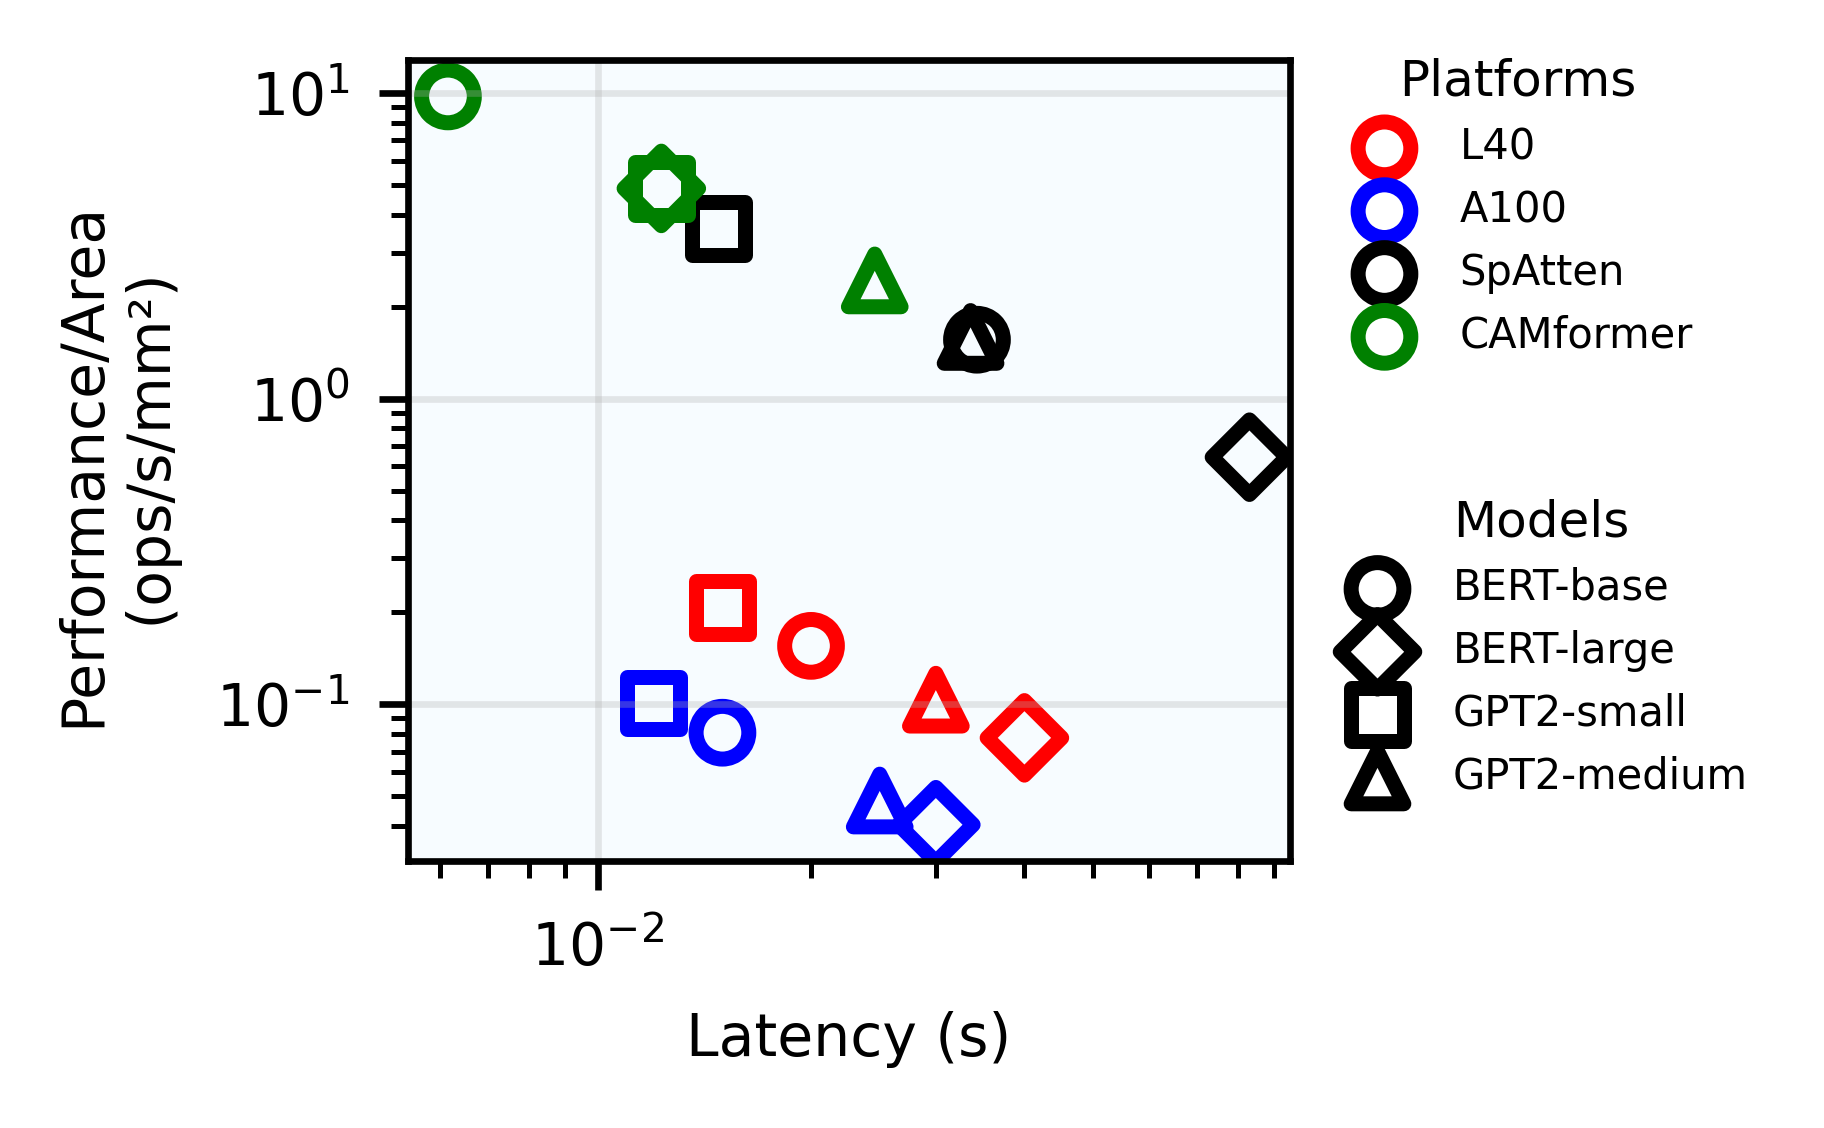

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Create figure with specified size and DPI
fig, ax = plt.subplots(figsize=(3.5*0.9, 2.2*0.9), dpi=600)

# Set the background color
ax.set_facecolor('#f7fcff')

# Data points (same as before)
platforms = {
   'L40': {
       'color': 'red',
       'area': 322,
       'BERT-base': (0.020, calc_perf_area(0.020, 322)),
       'BERT-large': (0.040, calc_perf_area(0.040, 322)),
       'GPT2-small': (0.015, calc_perf_area(0.015, 322)),
       'GPT2-medium': (0.030, calc_perf_area(0.030, 322))
   },
   'A100': {
       'color': 'blue',
       'area': 826,
       'BERT-base': (0.015, calc_perf_area(0.015, 826)),
       'BERT-large': (0.030, calc_perf_area(0.030, 826)),
       'GPT2-small': (0.012, calc_perf_area(0.012, 826)),
       'GPT2-medium': (0.025, calc_perf_area(0.025, 826))
   },
   'SpAtten': {
       'color': 'black',
       'area': 18.71,
       'BERT-base': (0.034286, calc_perf_area(0.034286, 18.71)),
       'BERT-large': (0.083076, calc_perf_area(0.083076, 18.71)),
       'GPT2-small': (0.014805, calc_perf_area(0.014805, 18.71)),
       'GPT2-medium': (0.033580, calc_perf_area(0.033580, 18.71))
   },
   'CAMformer': {
       'color': 'green',
       'area': 16.6817,
       'BERT-base': (6.15E-03, calc_perf_area(6.15E-03, 16.6817)),
       'BERT-large': (12.30E-03, calc_perf_area(12.30E-03, 16.6817)),
       'GPT2-small': (12.30E-03, calc_perf_area(12.30E-03, 16.6817)),
       'GPT2-medium': (24.60E-03, calc_perf_area(24.60E-03, 16.6817))
   }
}

# Define markers for different model types
markers = {
   'BERT-base': 'o',     # Circle
   'BERT-large': 'D',    # Diamond
   'GPT2-small': 's',    # Square
   'GPT2-medium': '^'    # Triangle
}

# Create handles for legends
platform_handles = []
model_handles = []

# Plot each platform
for platform, data in platforms.items():
   color = data['color']
   for model, marker in markers.items():
       scatter = ax.scatter(data[model][0], data[model][1],
                          marker=marker,
                          facecolor='none',
                          edgecolor=color,
                          linewidth=1.8,
                          s=40)

       if model == 'BERT-base':
           platform_handles.append(scatter)

# Create separate dummy points for model legend
for model, marker in markers.items():
   dummy = ax.scatter([], [],
                     color='black',
                     marker=marker,
                     facecolor='none',
                     edgecolor='black',
                     linewidth=1.8,
                     s=40,
                     label=model)
   model_handles.append(dummy)

# Add grid
plt.grid(True, alpha=0.3)

# Customize the plot
ax.set_xlabel('Latency (s)', fontsize=7)
ax.set_ylabel('Performance/Area \n (ops/s/mm²)', fontsize=7)
ax.tick_params(axis='both', labelsize=7)

# Set log scales
ax.set_xscale('log')
ax.set_yscale('log')

# Add two legends
leg1 = ax.legend(platform_handles, platforms.keys(),
               fontsize=5, frameon=False,
               title='Platforms', title_fontsize=6,
               bbox_to_anchor=(1.5, 1.05))
ax.add_artist(leg1)

leg2 = ax.legend(model_handles, markers.keys(),
               fontsize=5, frameon=False,
               title='Models', title_fontsize=6,
               bbox_to_anchor=(1.01, 0.5))

# Adjust layout
plt.tight_layout()

plt.show()